In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense

In [3]:
df = pd.read_csv('Tweets.csv')

In [4]:
df.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [5]:
df = df[['selected_text', 'sentiment']]
# df.columns = ['text', 'sentiment']
# df['text'] = df['text'].str.lower()
df.head()

,selected_text,sentiment
0,"I`d have responded, if I were going",neutral
1,Sooo SAD,negative
2,bullying me,negative
3,leave me alone,negative
4,"Sons of ****,",negative


In [6]:
df.dropna(inplace=True)

In [7]:
X = df['selected_text']
y = df['sentiment']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
Tokenizer = Tokenizer(num_words=8000)
Tokenizer.fit_on_texts(X_train)
X_train_seq = Tokenizer.texts_to_sequences(X_train)
X_test_seq = Tokenizer.texts_to_sequences(X_test)

In [10]:
X_train_pad = pad_sequences(X_train_seq, maxlen=50)
X_test_pad = pad_sequences(X_test_seq, maxlen=50)

In [11]:
def rnn_creation():
    model = Sequential()
    model.add(Embedding(8000, 128, input_length=50))
    model.add(SimpleRNN(32))
    model.add(Dense(3, activation='sigmoid'))
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

In [12]:
def LSTM_creation():
    model = Sequential()
    model.add(Embedding(8000, 128, input_length=50))
    model.add(LSTM(32))
    model.add(Dense(3, activation='sigmoid'))
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

In [13]:
rnn_model = rnn_creation()
lstm_model = LSTM_creation()

c:\Users\Lenovo\anaconda3\envs\tf310\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [14]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

rnn_history = rnn_model.fit(X_train_pad, y_train_encoded, epochs=10, batch_size=64, validation_split=0.2)

lstm_history = lstm_model.fit(X_train_pad, y_train_encoded, epochs=10, batch_size=64, validation_split=0.2)

Epoch 1/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.7495 - loss: 0.6325 - val_accuracy: 0.8208 - val_loss: 0.5083
Epoch 2/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8733 - loss: 0.3634 - val_accuracy: 0.8185 - val_loss: 0.5016
Epoch 3/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9158 - loss: 0.2491 - val_accuracy: 0.8115 - val_loss: 0.5434
Epoch 4/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9422 - loss: 0.1785 - val_accuracy: 0.8015 - val_loss: 0.6226
Epoch 5/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9554 - loss: 0.1375 - val_accuracy: 0.7962 - val_loss: 0.6726
Epoch 6/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9634 - loss: 0.1128 - val_accuracy: 0.7971 - val_loss: 0.7197
Epoch 7/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9701 - loss: 0.0946 - val_accuracy: 0.7960 - val_loss: 0.7829
Epoch 8/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9728 - loss: 0.0849 - val_accu

In [15]:
rnn_prob = rnn_model.predict(X_test_pad)
rnn_pred = np.argmax(rnn_prob, axis=1)
rnn_acc = accuracy_score(y_test_encoded, rnn_pred)

lstm_prod = lstm_model.predict(X_test_pad)
lstm_pred = np.argmax(lstm_prod, axis=1)
lstm_acc = accuracy_score(y_test_encoded, lstm_pred)


print(f"RNN Accuracy: {rnn_acc}")
print(f"LSTM Accuracy: {lstm_acc}")

172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
RNN Accuracy: 0.7874818049490538
LSTM Accuracy: 0.8025836972343523


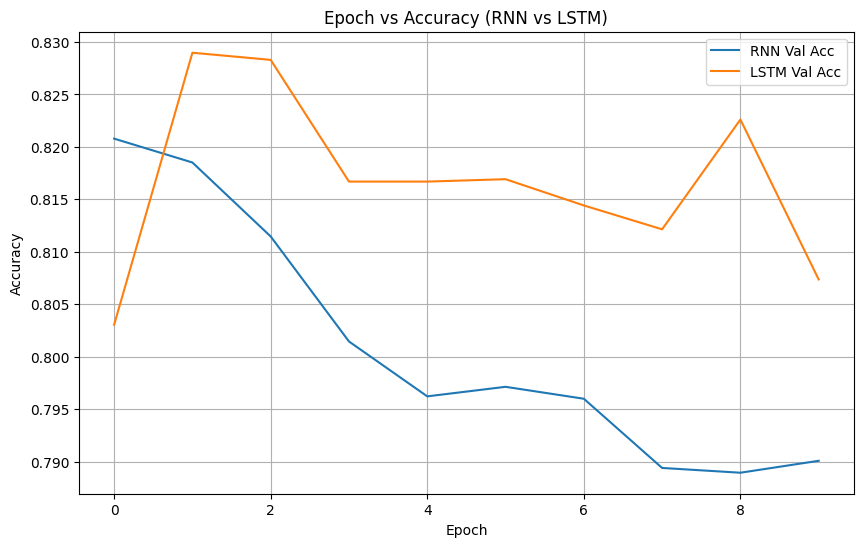

In [16]:
plt.figure(figsize=(10,6))

# plt.plot(rnn_history.history['accuracy'], label="RNN Train Acc")
plt.plot(rnn_history.history['val_accuracy'], label="RNN Val Acc")

# plt.plot(lstm_history.history['accuracy'], label="LSTM Train Acc")
plt.plot(lstm_history.history['val_accuracy'], label="LSTM Val Acc")

plt.title("Epoch vs Accuracy (RNN vs LSTM)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()